In [18]:
!pip install pyvi

In [30]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import classification_report, f1_score
import numpy as np
import json
import os
import math
from tqdm import tqdm
import logging
import matplotlib.pyplot as plt
from pyvi import ViTokenizer
# Tắt cảnh báo từ thư viện transformers
from transformers import logging as transformers_logging
transformers_logging.set_verbosity_error()



In [38]:

CONFIG = {
    # 1. Đường dẫn dữ liệu (Trỏ trực tiếp vào các file bạn đã split)
    # Bạn có thể đổi sang "MEDIUM_CONFIDENCE" nếu muốn train bộ kia
    'train_path': '/kaggle/input/datasets/kininhhng/rebalanced-dataset/dataset_rebalance_tokenizer_2_context/train.json',
    'val_path': '/kaggle/input/datasets/kininhhng/rebalanced-dataset/dataset_rebalance_tokenizer_2_context/val.json',
    'test_path': '/kaggle/input/datasets/kininhhng/rebalanced-dataset/dataset_rebalance_tokenizer_2_context/test.json',

    # 2. Cấu hình Model
    'model_name': 'vinai/phobert-base-v2', # Hoặc 'vinai/phobert-base-v2'
    'num_classes': 3,                    # SUPPORTED, NEI, REFUTED
    'max_length': 256,                   # Độ dài tối ưu khi tách lẻ Claim + 1 Context
    'dropout_prob': 0.3,

    # 3. Tham số Huấn luyện
    'batch_size': 8,                     # Điều chỉnh tùy theo VRAM của GPU (RTX 3090/4060 Ti của bạn)
    'accumulation_steps': 4,             # Effective batch size = 32
    'learning_rate': 2e-5,
    'weight_decay': 0.01,
    'patience': 4,                       # Dừng sớm nếu không cải thiện sau 4 epochs
    'save_path': 'best_phobert_factcheck_v4.pt',

    # 4. Focal Loss (Xử lý mất cân bằng nhãn)
    # Tăng trọng số cho lớp index 2 (REFUTED) vì thường nhãn này ít dữ liệu nhất
    'focal_alpha': [1.0, 1.0, 1.1], 
    'focal_gamma': 2.0,

    # 5. Chiến thuật Gradual Unfreezing (3 giai đoạn)
    'phases': {
        1: {
            'epochs': 3, 
            'unfreeze_layers': 0,        # Chỉ train classifier head
            'desc': 'Train Heads only'
        },
        2: {
            'epochs': 5, 
            'unfreeze_layers': 4,        # Mở 4 tầng cuối của PhoBERT (8-11)
            'desc': 'Fine-tune Top 4 layers'
        },
        3: {
            'epochs': 10, 
            'unfreeze_layers': 8,        # Mở 8 tầng cuối của PhoBERT (4-11)
            'desc': 'Fine-tune Top 8 layers'
        },
    }
}
def load_json_data(path):
        if os.path.exists(path):
            with open(path, 'r', encoding='utf-8') as f:
                return json.load(f)
        return None


In [32]:
# Tắt cảnh báo từ thư viện transformers
from transformers import logging as transformers_logging
transformers_logging.set_verbosity_error()

# =====================================================
# 1. CÁC MODULE CON
# =====================================================

class AttentionAggregator(nn.Module):
    """
    Attention-weighted sum: model tự học context nào quan trọng nhất.
    Thay thế torch.max (quá thô, mất thông tin).
    """
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 4),
            nn.Tanh(),
            nn.Linear(hidden_size // 4, 1)
        )

    def forward(self, stacked_cls):
        # 🌟 ĐỔI: stacked_cls: (batch, 2, hidden) thay vì 3
        attn_scores = self.attention(stacked_cls)             # (batch, 2, 1)
        attn_weights = torch.softmax(attn_scores / 0.5, dim=1) # Temperature = 0.5
        output = (stacked_cls * attn_weights).sum(dim=1)   # (batch, hidden)
        return output, attn_weights.squeeze(-1)


class CrossContextEncoder(nn.Module):
    """
    Cho 2 CLS vectors tương tác qua Self-Attention.
    Phát hiện mâu thuẫn (REFUTED) hoặc nhất quán (SUPPORTED) giữa các context.
    """
    def __init__(self, hidden_size, num_heads=8, num_layers=1, dropout=0.1):
        super().__init__()
        # 🌟 ĐẢM BẢO: nhead phải chia hết cho hidden_size (mặc định PhoBERT là 768 / 8 = 96 -> OK)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=num_heads,
            dim_feedforward=hidden_size * 2,
            dropout=dropout,
            activation='gelu',
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.layer_norm = nn.LayerNorm(hidden_size)

    def forward(self, stacked_cls):
        encoded = self.transformer(stacked_cls)
        return self.layer_norm(encoded + stacked_cls)  # residual


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, num_classes=3):
        super().__init__()
        self.gamma = gamma
        if alpha is None:
            self.alpha = torch.ones(num_classes)
        else:
            self.alpha = torch.tensor(alpha, dtype=torch.float)

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        alpha_t = self.alpha.to(logits.device)[targets]
        focal_loss = alpha_t * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()


# =====================================================
# 2. MÔ HÌNH CHÍNH
# =====================================================

class PhoBERTFactChecker(nn.Module):
    def __init__(self, model_name="vinai/phobert-base-v2", num_classes=3, dropout_prob=0.3, use_cross_encoder=False):
        super().__init__()
        self.phobert = AutoModel.from_pretrained(model_name)
        hidden = self.phobert.config.hidden_size
        
        # Thêm CrossContextEncoder nếu bạn muốn 2 CLS tương tác trực tiếp với nhau trước khi Aggregate
        self.use_cross_encoder = use_cross_encoder
        if self.use_cross_encoder:
            self.cross_encoder = CrossContextEncoder(hidden_size=hidden)
            
        # Attention Aggregator
        self.aggregator = AttentionAggregator(hidden_size=hidden)
    
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_prob),
            nn.Linear(hidden, hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout_prob / 2),
            nn.Linear(hidden // 2, num_classes)
        )

    def _encode_pair(self, input_ids, attention_mask):
        output = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        return output.last_hidden_state[:, 0, :] # Trích xuất token [CLS]
    
    # 🌟 ĐỔI: Chỉ nhận đầu vào của 2 cặp context thay vì 3
    def forward(self, input_ids_1, attention_mask_1, input_ids_2, attention_mask_2):
        # 1. Trích xuất [CLS] token của 2 context
        cls_1 = self._encode_pair(input_ids_1, attention_mask_1)
        cls_2 = self._encode_pair(input_ids_2, attention_mask_2)
    
        # 2. Gom 2 vector lại thành tensor (batch, 2, hidden)
        stacked_cls = torch.stack([cls_1, cls_2], dim=1)
        
        # Thêm bước tương tác chéo nếu được bật
        if self.use_cross_encoder:
            stacked_cls = self.cross_encoder(stacked_cls)
        
        # 3. Dùng Attention để tự động tính tổng có trọng số
        fused_cls, attn_weights = self.aggregator(stacked_cls) # fused_cls: (batch, hidden)
    
        # 4. Đưa qua Classifier
        logits = self.classifier(fused_cls)
    
        return logits, attn_weights

# =====================================================
# 3. DATASET
# =====================================================

class FactCheckingDataset(Dataset):
    LABEL_MAP = {"SUPPORTED": 0, "NEI": 1, "REFUTED": 2}

    def __init__(self, data, model_name="vinai/phobert-base", max_length=256):
        self.data = data
        self.max_length = max_length
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        
        # Tách từ cho câu Claim
        raw_claim = str(item.get("claim", ""))
        claim = ViTokenizer.tokenize(raw_claim)
        
        raw = item.get("contexts", item.get("evidence", []))
        def get_ctx(i):
            if i >= len(raw): return ""
            c = raw[i]
            return c if isinstance(c, str) else c.get("text", "")
    
        # 🌟 ĐỔI: Chỉ lấy và tokenize 2 context
        ctx_1 = ViTokenizer.tokenize(str(get_ctx(0)))
        ctx_2 = ViTokenizer.tokenize(str(get_ctx(1)))
        
        label_str = item.get("final_label", item.get("label", "NEI"))
        if isinstance(label_str, str):
            label = self.LABEL_MAP.get(label_str.upper(), 1)
        else:
            label = label_str

        # Tokenize 2 cặp
        enc_1 = self.tokenizer(claim, ctx_1, padding="max_length", truncation=True,
                            max_length=self.max_length, return_tensors='pt')
        enc_2 = self.tokenizer(claim, ctx_2, padding="max_length", truncation=True,
                            max_length=self.max_length, return_tensors='pt')

        # 🌟 ĐỔI: Chỉ return data của 2 cặp
        return {
            "input_ids_1": enc_1["input_ids"].squeeze(0),
            "attention_mask_1": enc_1["attention_mask"].squeeze(0),
            "input_ids_2": enc_2["input_ids"].squeeze(0),
            "attention_mask_2": enc_2["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long)
        }


# =====================================================
# 4. GRADUAL UNFREEZING — CORE LOGIC
# =====================================================

def freeze_phobert(model):
    m = model.module if hasattr(model, 'module') else model
    for param in m.phobert.parameters():
        param.requires_grad = False
    print("❄️  PhoBERT: FROZEN (tất cả 12 layers)")


def unfreeze_top_n_layers(model, n):
    m = model.module if hasattr(model, 'module') else model
    total_layers = len(m.phobert.encoder.layer)
    start_layer = total_layers - n
    for i, layer in enumerate(m.phobert.encoder.layer):
        for param in layer.parameters():
            param.requires_grad = (i >= start_layer)
    for param in m.phobert.embeddings.parameters():
        param.requires_grad = False

    frozen = [i for i in range(start_layer)]
    unfrozen = [i for i in range(start_layer, total_layers)]
    print(f"🔥 PhoBERT: Unfroze layers {unfrozen}")
    print(f"❄️  PhoBERT: Still frozen {frozen} + embeddings")


def count_trainable_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = total - trainable
    print(f"   📊 Total: {total:,} | Trainable: {trainable:,} ({100*trainable/total:.1f}%) | Frozen: {frozen:,}")
    return trainable


def get_optimizer_for_phase(model, phase, base_lr=2e-5):
    m = model.module if hasattr(model, 'module') else model
    param_groups = []

    # Thu gom các tham số ngoài PhoBERT để train với LR cao hơn
    head_params = list(m.classifier.parameters()) + list(m.aggregator.parameters())
    if m.use_cross_encoder:
        head_params += list(m.cross_encoder.parameters())

    if phase == 1:
        param_groups.append({
            'params': head_params,
            'lr': base_lr * 10,  # 2e-4
            'weight_decay': 0.01
        })
    elif phase == 2:
        param_groups.append({
            'params': head_params,
            'lr': base_lr * 5,   # 1e-4
            'weight_decay': 0.01
        })
        phobert_unfrozen = [p for p in m.phobert.parameters() if p.requires_grad]
        if phobert_unfrozen:
            param_groups.append({
                'params': phobert_unfrozen,
                'lr': base_lr,   # 2e-5
                'weight_decay': 0.01
            })
    elif phase == 3:
        param_groups.append({
            'params': head_params,
            'lr': base_lr * 2,   # 4e-5
            'weight_decay': 0.01
        })
        phobert_unfrozen = [p for p in m.phobert.parameters() if p.requires_grad]
        if phobert_unfrozen:
            param_groups.append({
                'params': phobert_unfrozen,
                'lr': base_lr * 0.5,  # 1e-5
                'weight_decay': 0.01
            })

    return torch.optim.AdamW(param_groups)


# =====================================================
# 5. TRAINING UTILITIES
# =====================================================

def train_one_epoch(model, dataloader, criterion, optimizer, scheduler, device, accumulation_steps=4):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    optimizer.zero_grad()
    progress_bar = tqdm(dataloader, desc="Training")

    for step, batch in enumerate(progress_bar):
        input_data = {k: v.to(device) for k, v in batch.items() if k != 'label'}
        labels = batch['label'].to(device)

        # 🌟 ĐỔI: Chỉ truyền 2 cặp đầu vào vào model
        logits, _ = model(
            input_ids_1=input_data['input_ids_1'], attention_mask_1=input_data['attention_mask_1'],
            input_ids_2=input_data['input_ids_2'], attention_mask_2=input_data['attention_mask_2']
        )

        loss = criterion(logits, labels)
        loss = loss / accumulation_steps
        loss.backward()

        total_loss += loss.item() * accumulation_steps
        preds = torch.argmax(logits, dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

        if (step + 1) % accumulation_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        progress_bar.set_postfix({
            'loss': f'{loss.item() * accumulation_steps:.4f}',
            'lr': f'{scheduler.get_last_lr()[0]:.2e}'
        })

    if (step + 1) % accumulation_steps != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    avg_loss = total_loss / len(dataloader)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, f1


@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_attn_weights = []

    for batch in tqdm(dataloader, desc="Evaluating"):
        input_data = {k: v.to(device) for k, v in batch.items() if k != 'label'}
        labels = batch['label'].to(device)

        # 🌟 ĐỔI: Chỉ truyền 2 cặp đầu vào vào model
        logits, attn_weights = model(
            input_ids_1=input_data['input_ids_1'], attention_mask_1=input_data['attention_mask_1'],
            input_ids_2=input_data['input_ids_2'], attention_mask_2=input_data['attention_mask_2']
        )

        loss = criterion(logits, labels)
        total_loss += loss.item()

        preds = torch.argmax(logits, dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        all_attn_weights.extend(attn_weights.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    f1 = f1_score(all_labels, all_preds, average='macro')
    label_names = ["SUPPORTED", "NEI", "REFUTED"]
    report = classification_report(all_labels, all_preds, target_names=label_names, digits=4)

    return avg_loss, f1, report, np.array(all_attn_weights)

# =====================================================
# 6. MAIN TRAINING — GRADUAL UNFREEZING
# =====================================================
def train_gradual_unfreeze(model, train_dataset, val_dataset, config):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🖥️  Using device: {device}")
    model = model.to(device)

    if torch.cuda.device_count() > 1:
        print(f"🖥️  Dùng {torch.cuda.device_count()} GPUs: DataParallel")
        model = nn.DataParallel(model)

    phase_config = config.get('phases', {
        1: {'epochs': 3, 'unfreeze_layers': 0},
        2: {'epochs': 5, 'unfreeze_layers': 4},
        3: {'epochs': 7, 'unfreeze_layers': 8},
    })

    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'] * 2, shuffle=False, num_workers=2, pin_memory=True)

    criterion = FocalLoss(
        alpha=config.get('focal_alpha', [1.0, 1.0, 1.2]),
        gamma=config.get('focal_gamma', 2.0)
    )

    best_f1 = 0.0
    patience = config.get('patience', 4)
    global_epoch = 0
    history = {'train_loss': [], 'train_f1': [], 'val_loss': [], 'val_f1': []}
    last_phase = max(phase_config.keys())

    for phase_num in sorted(phase_config.keys()):
        phase = phase_config[phase_num]
        phase_epochs = phase['epochs']
        unfreeze_n = phase['unfreeze_layers']

        print(f"\n{'='*70}")
        print(f"🌊 PHASE {phase_num}: ", end="")
        if unfreeze_n == 0:
            print("PhoBERT FROZEN → Train heads only")
            freeze_phobert(model)
        else:
            print(f"Unfreeze top {unfreeze_n} PhoBERT layers")
            unfreeze_top_n_layers(model, unfreeze_n)

        count_trainable_params(model)

        optimizer = get_optimizer_for_phase(model, phase_num, config['learning_rate'])
        total_steps = len(train_loader) * phase_epochs // config['accumulation_steps']
        warmup_steps = int(0.06 * total_steps)
        scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

        for i, pg in enumerate(optimizer.param_groups):
            print(f"   Param group {i}: LR = {pg['lr']:.2e}, Params = {sum(p.numel() for p in pg['params']):,}")
        print(f"{'='*70}\n")

        phase_best_f1 = 0.0
        patience_counter = 0

        for epoch in range(phase_epochs):
            global_epoch += 1
            print(f"\n--- Phase {phase_num} | Epoch {epoch+1}/{phase_epochs} (Global: {global_epoch}) ---")

            train_loss, train_f1 = train_one_epoch(
                model, train_loader, criterion, optimizer, scheduler, device,
                accumulation_steps=config['accumulation_steps']
            )

            val_loss, val_f1, val_report, attn_weights = evaluate(
                model, val_loader, criterion, device
            )

            history['train_loss'].append(train_loss)
            history['train_f1'].append(train_f1)
            history['val_loss'].append(val_loss)
            history['val_f1'].append(val_f1)

            print(f"\n📈 Results:")
            print(f"   Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f}")
            print(f"   Val   Loss: {val_loss:.4f} | Val   F1: {val_f1:.4f}")
            print(f"\n{val_report}")

            mean_attn = attn_weights.mean(axis=0)
            # 🌟 ĐỔI: Chỉ in trọng số của 2 contexts
            print(f"   📊 Avg Attn: Ctx1={mean_attn[0]:.3f}, Ctx2={mean_attn[1]:.3f}")

            if val_f1 > phase_best_f1:
                phase_best_f1 = val_f1

            if val_f1 > best_f1:
                best_f1 = val_f1
                patience_counter = 0
                save_path = f'best_model_{phase_num}_{epoch+1}_{phase_epochs}.pt'
                torch.save({
                    'global_epoch': global_epoch,
                    'phase': phase_num,
                    'model_state_dict': model.module.state_dict() if hasattr(model, 'module') else model.state_dict(),
                    'val_f1': val_f1,
                    'val_loss': val_loss,
                }, save_path)
                print(f"   ✅ BEST MODEL SAVED! F1 = {val_f1:.4f}")
            else:
                patience_counter += 1
                print(f"   ⚠️  No global improvement. Patience: {patience_counter}/{patience}")

                if patience_counter >= patience:
                    if phase_num == last_phase:
                        print(f"\n🛑 Early stopping! Phase cuối hết patience tại epoch {global_epoch}.")
                    else:
                        print(f"\n⏭️  Phase {phase_num} hết patience → chuyển phase {phase_num + 1}.")
                    break

        print(f"\n🏁 Phase {phase_num} complete. Best phase F1: {phase_best_f1:.4f} | Best global F1: {best_f1:.4f}")
        if patience_counter >= patience and phase_num == last_phase:
            break

    print(f"\n{'='*70}")
    print(f"🏆 TRAINING COMPLETE. Best Val F1: {best_f1:.4f}")
    print(f"{'='*70}")

    return best_f1, history

In [39]:

if __name__ == "__main__":



    # 1. Load Data trực tiếp từ các file đã chia
   

    train_data = load_json_data(CONFIG['train_path'])
    val_data = load_json_data(CONFIG['val_path'])
    test_data = load_json_data(CONFIG['test_path'])

    if train_data and val_data:
        print(f"✅ Loaded: Train({len(train_data)}), Val({len(val_data)}), Test({len(test_data)})")
        
        # 2. Khởi tạo Dataset (Giữ nguyên class FactCheckingDataset cũ)
        train_dataset = FactCheckingDataset(train_data, CONFIG['model_name'], CONFIG['max_length'])
        val_dataset = FactCheckingDataset(val_data, CONFIG['model_name'], CONFIG['max_length'])
        test_dataset = FactCheckingDataset(test_data, CONFIG['model_name'], CONFIG['max_length'])

        # 3. Khởi tạo Model
        model = PhoBERTFactChecker(
            model_name=CONFIG['model_name'],
            num_classes=CONFIG['num_classes'],
            dropout_prob=CONFIG['dropout_prob']
        )

        # 4. Tiến hành Train (Hàm train_gradual_unfreeze sẽ tự lấy config['phases'])
        best_f1, history = train_gradual_unfreeze(model, train_dataset, val_dataset, CONFIG)
    else:
        print("❌ Lỗi: Không tìm thấy các file dữ liệu trong thư mục đã chỉ định.")

✅ Loaded: Train(3599), Val(750), Test(888)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

🖥️  Using device: cuda
🖥️  Dùng 2 GPUs: DataParallel

🌊 PHASE 1: PhoBERT FROZEN → Train heads only
❄️  PhoBERT: FROZEN (tất cả 12 layers)
   📊 Total: 135,442,564 | Trainable: 444,292 (0.3%) | Frozen: 134,998,272
   Param group 0: LR = 0.00e+00, Params = 444,292


--- Phase 1 | Epoch 1/3 (Global: 1) ---


Evaluating: 100%|██████████| 47/47 [00:13<00:00,  3.40it/s]



📈 Results:
   Train Loss: 0.4909 | Train F1: 0.3972
   Val   Loss: 0.4769 | Val   F1: 0.4286

              precision    recall  f1-score   support

   SUPPORTED     0.4610    0.5440    0.4991       250
         NEI     0.4937    0.1560    0.2371       250
     REFUTED     0.4574    0.6880    0.5495       250

    accuracy                         0.4627       750
   macro avg     0.4707    0.4627    0.4286       750
weighted avg     0.4707    0.4627    0.4286       750

   📊 Avg Attn: Ctx1=0.501, Ctx2=0.499
   ✅ BEST MODEL SAVED! F1 = 0.4286

--- Phase 1 | Epoch 2/3 (Global: 2) ---


...


📈 Results:
   Train Loss: 0.0782 | Train F1: 0.9068
   Val   Loss: 0.2809 | Val   F1: 0.7794

              precision    recall  f1-score   support

   SUPPORTED     0.7903    0.7840    0.7871       250
         NEI     0.8430    0.7520    0.7949       250
     REFUTED     0.7168    0.8000    0.7561       250

    accuracy                         0.7787       750
   macro avg     0.7834    0.7787    0.7794       750
weighted avg     0.7834    0.7787    0.7794       750

   📊 Avg Attn: Ctx1=0.528, Ctx2=0.472
   ⚠️  No global improvement. Patience: 1/4

--- Phase 3 | Epoch 6/7 (Global: 14) ---


Evaluating: 100%|██████████| 47/47 [00:13<00:00,  3.39it/s]



📈 Results:
   Train Loss: 0.0640 | Train F1: 0.9273
   Val   Loss: 0.2799 | Val   F1: 0.7948

              precision    recall  f1-score   support

   SUPPORTED     0.8170    0.7680    0.7918       250
         NEI     0.8142    0.8240    0.8191       250
     REFUTED     0.7557    0.7920    0.7734       250

    accuracy                         0.7947       750
   macro avg     0.7957    0.7947    0.7948       750
weighted avg     0.7957    0.7947    0.7948       750

   📊 Avg Attn: Ctx1=0.525, Ctx2=0.475
   ✅ BEST MODEL SAVED! F1 = 0.7948

--- Phase 3 | Epoch 7/7 (Global: 15) ---


Evaluating: 100%|██████████| 47/47 [00:14<00:00,  3.32it/s]



📈 Results:
   Train Loss: 0.0551 | Train F1: 0.9328
   Val   Loss: 0.2851 | Val   F1: 0.7948

              precision    recall  f1-score   support

   SUPPORTED     0.8386    0.7480    0.7907       250
         NEI     0.8118    0.8280    0.8198       250
     REFUTED     0.7426    0.8080    0.7739       250

    accuracy                         0.7947       750
   macro avg     0.7977    0.7947    0.7948       750
weighted avg     0.7977    0.7947    0.7948       750

   📊 Avg Attn: Ctx1=0.525, Ctx2=0.475
   ✅ BEST MODEL SAVED! F1 = 0.7948

🏁 Phase 3 complete. Best phase F1: 0.7948 | Best global F1: 0.7948

🏆 TRAINING COMPLETE. Best Val F1: 0.7948


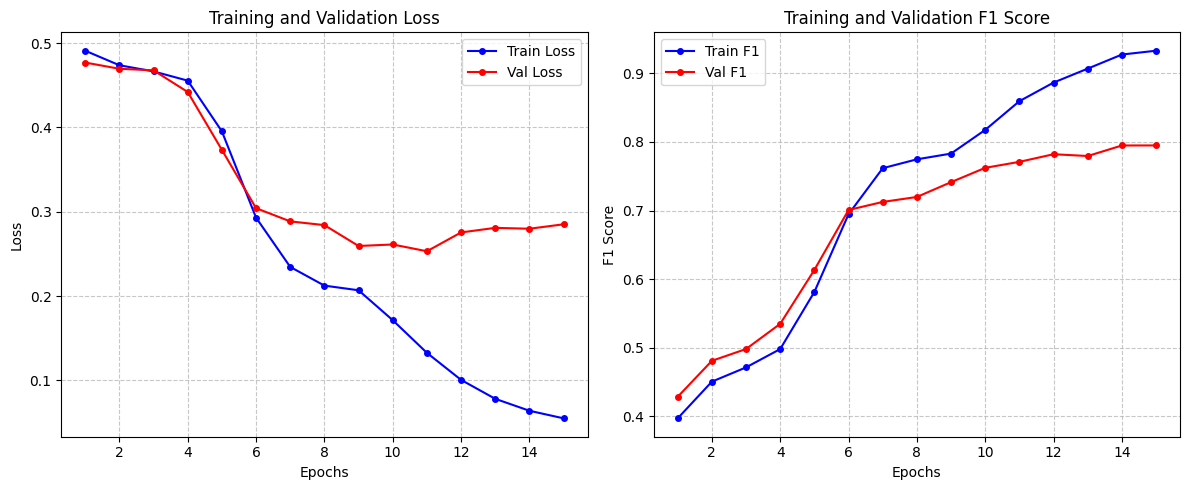

📉 Learning curves saved to learning_curve.png


In [40]:
plot_learning_curves(history)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

✅ Loaded model from 'best_phobert_factcheck_v4.pt'
   Saved at Global Epoch 14 | Phase 3
   Val F1 = 0.7948 | Val Loss = 0.2799


🔍 Inference: 100%|██████████| 56/56 [00:23<00:00,  2.33it/s]



🏆 Test Macro F1: 0.7227
              precision    recall  f1-score   support

   SUPPORTED     0.7799    0.7025    0.7392       353
         NEI     0.8655    0.8222    0.8433       360
     REFUTED     0.5175    0.6743    0.5856       175

    accuracy                         0.7455       888
   macro avg     0.7210    0.7330    0.7227       888
weighted avg     0.7629    0.7455    0.7511       888

📊 Avg Attention Weights:
   Context 1: 0.5270
   Context 2: 0.4730


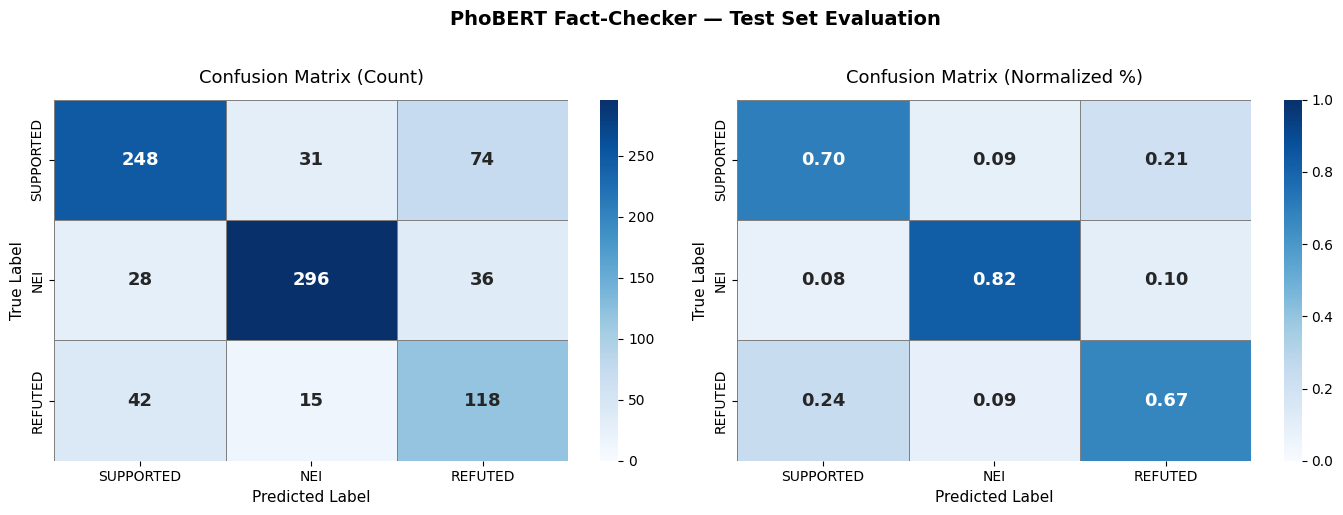

📊 Confusion matrix saved to 'confusion_matrix_test.png'


In [42]:
# =====================================================
# 9. INFERENCE & CONFUSION MATRIX
# =====================================================

import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, classification_report
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
import torch

LABEL_NAMES = ["SUPPORTED", "NEI", "REFUTED"]

# ---------------------------------------------------
# 9.1. Load model đã lưu
# ---------------------------------------------------

def load_best_model(config, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Khởi tạo mô hình 2 cặp
    model = PhoBERTFactChecker(
        model_name=config['model_name'],
        num_classes=config['num_classes'],
        dropout_prob=config['dropout_prob']
    )

    checkpoint = torch.load("best_model_3_6_7.pt", map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()

    print(f"✅ Loaded model from '{config['save_path']}'")
    print(f"   Saved at Global Epoch {checkpoint['global_epoch']} | Phase {checkpoint['phase']}")
    print(f"   Val F1 = {checkpoint['val_f1']:.4f} | Val Loss = {checkpoint['val_loss']:.4f}")
    return model, device


# ---------------------------------------------------
# 9.2. Inference trên toàn bộ test set
# ---------------------------------------------------

@torch.no_grad()
def run_inference(model, dataloader, device):
    """Chạy inference cho mô hình 2 cặp, trả về predictions, labels, attention weights."""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    all_attn = []

    for batch in tqdm(dataloader, desc="🔍 Inference"):
        input_data = {k: v.to(device) for k, v in batch.items() if k != 'label'}
        labels = batch['label']

        # 🌟 ĐỔI: Chỉ truyền 2 cặp đầu vào vào model thay vì 3
        logits, attn_weights = model(
            input_ids_1=input_data['input_ids_1'], attention_mask_1=input_data['attention_mask_1'],
            input_ids_2=input_data['input_ids_2'], attention_mask_2=input_data['attention_mask_2']
        )

        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        preds = np.argmax(probs, axis=-1)

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)
        all_attn.extend(attn_weights.cpu().numpy())

    return (
        np.array(all_preds),
        np.array(all_labels),
        np.array(all_probs),
        np.array(all_attn)
    )


# ---------------------------------------------------
# 9.3. Vẽ Confusion Matrix
# ---------------------------------------------------

def plot_confusion_matrix(y_true, y_pred, label_names=LABEL_NAMES,
                          save_path="confusion_matrix.png", normalize=True):
    """
    Vẽ confusion matrix đẹp với seaborn.
    normalize=True → hiển thị tỉ lệ %, dễ so sánh khi data imbalanced.
    """
    cm = confusion_matrix(y_true, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, norm, title_suffix in zip(
        axes,
        [False, True],
        ["(Count)", "(Normalized %)"]
    ):
        if norm:
            cm_plot = cm.astype(float) / cm.sum(axis=1, keepdims=True)
            fmt = ".2f"
            vmax = 1.0
        else:
            cm_plot = cm
            fmt = "d"
            vmax = cm.max()

        sns.heatmap(
            cm_plot,
            annot=True,
            fmt=fmt,
            cmap="Blues",
            xticklabels=label_names,
            yticklabels=label_names,
            linewidths=0.5,
            linecolor='gray',
            vmin=0,
            vmax=vmax,
            ax=ax,
            annot_kws={"size": 13, "weight": "bold"}
        )
        ax.set_title(f"Confusion Matrix {title_suffix}", fontsize=13, pad=12)
        ax.set_xlabel("Predicted Label", fontsize=11)
        ax.set_ylabel("True Label", fontsize=11)
        ax.tick_params(axis='both', labelsize=10)

    plt.suptitle("PhoBERT Fact-Checker — Test Set Evaluation", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"📊 Confusion matrix saved to '{save_path}'")
    return cm


# ---------------------------------------------------
# 9.4. Chạy toàn bộ pipeline inference
# ---------------------------------------------------

def evaluate_on_test(config):
    # Load model
    model, device = load_best_model(config)

    # Load test data
    test_data = load_json_data(config['test_path'])
    if test_data is None:
        print("❌ Không tìm thấy test data.")
        return

    # Khởi tạo dataset 2 cặp mới
    test_dataset = FactCheckingDataset(test_data, config['model_name'], config['max_length'])
    test_loader = DataLoader(
        test_dataset,
        batch_size=config['batch_size'] * 2,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    # Inference
    preds, labels, probs, attn_weights = run_inference(model, test_loader, device)

    # Metrics
    test_f1 = f1_score(labels, preds, average='macro')
    report = classification_report(labels, preds, target_names=LABEL_NAMES, digits=4)
    print(f"\n{'='*60}")
    print(f"🏆 Test Macro F1: {test_f1:.4f}")
    print(f"{'='*60}")
    print(report)

    # 🌟 ĐỔI: Chỉ tính và hiển thị Attention Weights cho 2 Context
    mean_attn = attn_weights.mean(axis=0)
    print(f"📊 Avg Attention Weights:")
    for i, w in enumerate(mean_attn):
        print(f"   Context {i+1}: {w:.4f}")

    # Confusion matrix
    cm = plot_confusion_matrix(labels, preds, save_path="confusion_matrix_test.png")

    return {
        'preds': preds,
        'labels': labels,
        'probs': probs,
        'attn_weights': attn_weights,
        'f1': test_f1,
        'report': report,
        'confusion_matrix': cm
    }


# ---------------------------------------------------
# RUN
# ---------------------------------------------------

results = evaluate_on_test(CONFIG)